In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/6_49.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/9_24.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/5_19.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/5_5.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/4_9.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/9_19.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/9_73.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/4_18.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/9_8.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/9_58.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/6_36.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/2_3.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/6_50.wav
/kaggle/input/major-vs-minor-guitar-chords/shords_datas

![](https://i.ytimg.com/vi/H1_9isNISw8/maxresdefault.jpg)youtube.com

#Code by Salman Ibne Eunus https://www.kaggle.com/salmaneunus/a-basic-guide-to-speech-recognition-2

In [2]:
frequency_sampling, audio_signal = wavfile.read("../input/major-vs-minor-guitar-chords/shords_dataset/major/4_9.wav")

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  """Entry point for launching an IPython kernel.


In [3]:
print('\nSignal shape:', audio_signal.shape)
print('Signal Datatype:', audio_signal.dtype)
print('Signal duration:', round(audio_signal.shape[0] / 
float(frequency_sampling), 2), 'seconds')


Signal shape: (135292, 2)
Signal Datatype: float32
Signal duration: 3.07 seconds


In [4]:
audio_signal = audio_signal / np.power(2, 15)

In [5]:
audio_signal = audio_signal [:100]
time_axis = 1000 * np.arange(0, len(audio_signal), 1) / float(frequency_sampling)

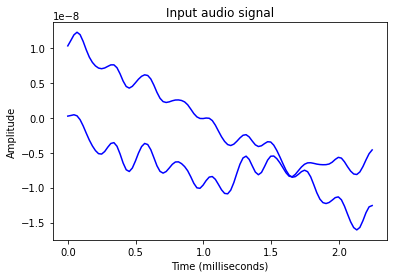

In [6]:
plt.plot(time_axis, audio_signal, color='blue')
plt.xlabel('Time (milliseconds)')
plt.ylabel('Amplitude')
plt.title('Input audio signal')
plt.show()

#Characterizing the audio signal

In [7]:
length_signal = len(audio_signal)
half_length = np.ceil((length_signal + 1) / 2.0).astype(np.int)

In [8]:
signal_frequency = np.fft.fft(audio_signal)

In [9]:
signal_frequency = abs(signal_frequency[0:half_length]) / length_signal
signal_frequency **= 2

In [10]:
len_fts = len(signal_frequency)

In [11]:
if length_signal % 2:
   signal_frequency[1:len_fts] *= 2
else:
   signal_frequency[1:len_fts-1] *= 2

In [12]:
signal_power = 10 * np.log10(signal_frequency)

In [13]:
x_axis = np.arange(0, half_length, 1) * (frequency_sampling / length_signal) / 1000.0

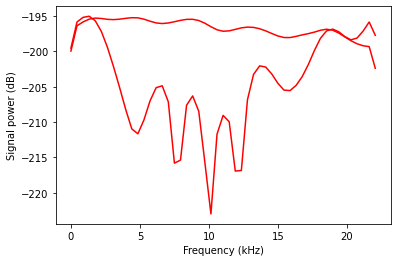

In [14]:
plt.figure()
plt.plot(x_axis, signal_power, color='red')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Signal power (dB)')
plt.show()

In [15]:
!pip install SpeechRecognition

     |████████████████████████████████| 32.8 MB 14.8 MB/s 


In [16]:
import speech_recognition as sr
sr.__version__

'3.8.1'

#Recognizer class

In [17]:
r = sr.Recognizer()

#Loading an audio file

In [18]:
deam = sr.AudioFile('../input/major-vs-minor-guitar-chords/shords_dataset/minor/1_20.wav')

In [19]:
with deam as source:
    audio = r.record(source)

ValueError: Audio file could not be read as PCM WAV, AIFF/AIFF-C, or Native FLAC; check if file is corrupted or in another format

#Since I can't find out why it went wrong. Let's go to Plan B to hear a Major sound!

In [20]:
import librosa
import librosa.display
import json
import tensorflow as tf
from matplotlib.pyplot import specgram
import glob 
import os
from tqdm import tqdm
import pickle
import IPython.display as ipd  # To play sound in the notebook

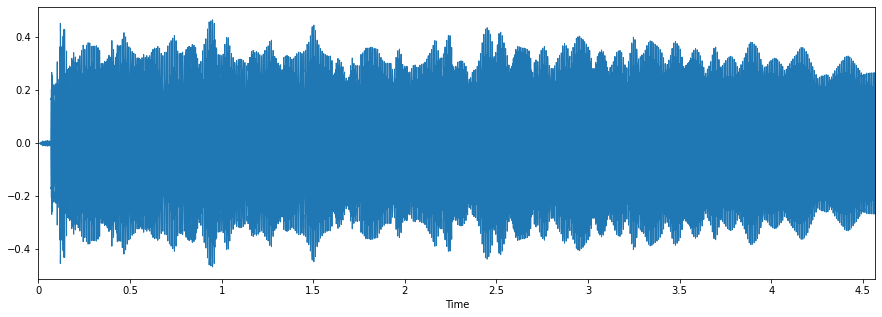

In [21]:
# Use one audio file in previous parts again
fname = '/kaggle/input/major-vs-minor-guitar-chords/shords_dataset/major/2_12.wav'  
data, sampling_rate = librosa.load(fname)
plt.figure(figsize=(15, 5))
librosa.display.waveplot(data, sr=sampling_rate)

# Paly it again to refresh our memory
ipd.Audio(data, rate=sampling_rate)

In [22]:
#Code by Olga Belitskaya https://www.kaggle.com/olgabelitskaya/sequential-data/comments
from IPython.display import display,HTML
c1,c2,f1,f2,fs1,fs2=\
'#eb3434','#eb3446','Akronim','Smokum',30,15
def dhtml(string,fontcolor=c1,font=f1,fontsize=fs1):
    display(HTML("""<style>
    @import 'https://fonts.googleapis.com/css?family="""\
    +font+"""&effect=3d-float';</style>
    <h1 class='font-effect-3d-float' style='font-family:"""+\
    font+"""; color:"""+fontcolor+"""; font-size:"""+\
    str(fontsize)+"""px;'>%s</h1>"""%string))
    
    
dhtml('Be patient. Marília Prata, @mpwolke was Here' )